# Week 4 · Day 3 — Build & Ship: Numeric Data Analyzer
### Code to AI — Python & Data Science (from Zero to Portfolio)
**Instructor:** Ali Hasnain

---
**Goal for today:** load a **real CSV** into NumPy, compute summary statistics, answer real questions, and push the project to GitHub. This is your Week 4 portfolio project! 🚀

**Session plan (~75 min):**
| Time | Segment |
|------|---------|
| 0–8 min | The project & the dataset |
| 8–25 min | Loading a CSV with NumPy |
| 25–45 min | Summary statistics on real columns |
| 45–60 min | Answering real questions (masks + where) |
| 60–70 min | README + push to GitHub |
| 70–75 min | 2-minute demos |

> **Dataset:** we provide two options — `weather_week.csv` and `sports_scores.csv`. Pick whichever you like; the code is the same idea. This notebook uses the **weather** file; swap the filename to use sports.

## 1. The project (0–8 min)

We have a real CSV of daily weather. Our job: load it, summarize it, and answer useful questions like *"What was the hottest day?"* and *"How many days did it rain?"*

**The weather dataset columns:**
`day, temp_c, humidity, rainfall_mm, wind_kmh`

(The sports dataset columns are: `match, points_scored, points_allowed, rebounds, assists`.)

## 2. Loading a CSV with NumPy (8–25 min)

We use `np.genfromtxt` to read a CSV file into an array.
- `delimiter=","` → columns are separated by commas
- `skip_header=1` → skip the header row (the column names)
- `names=True` → read the header so we can access columns **by name**

The second version (`names=True`) is the friendliest — we get columns like `data['temp_c']`.

In [1]:
import numpy as np

# Load with column names (so we can use data['temp_c'], etc.)
data = np.genfromtxt("data/weather_week.csv", delimiter=",", names=True)



In [2]:
data

array([( 1., 31., 45.,  0., 12.), ( 2., 34., 40.,  0., 15.),
       ( 3., 29., 60.,  5., 20.), ( 4., 27., 72., 12., 18.),
       ( 5., 33., 38.,  0., 10.), ( 6., 36., 35.,  0.,  8.),
       ( 7., 30., 55.,  3., 14.), ( 8., 28., 68.,  9., 22.),
       ( 9., 35., 42.,  0., 11.), (10., 32., 50.,  1., 16.),
       (11., 26., 80., 18., 25.), (12., 37., 30.,  0.,  7.),
       (13., 33., 44.,  0., 13.), (14., 30., 58.,  4., 17.)],
      dtype=[('day', '<f8'), ('temp_c', '<f8'), ('humidity', '<f8'), ('rainfall_mm', '<f8'), ('wind_kmh', '<f8')])

In [3]:
print("column names:", data.dtype.names)


column names: ('day', 'temp_c', 'humidity', 'rainfall_mm', 'wind_kmh')


In [5]:
data.shape

(14,)

In [6]:
data['wind_kmh']

array([12., 15., 20., 18., 10.,  8., 14., 22., 11., 16., 25.,  7., 13.,
       17.])

In [4]:
print("number of days:", data.shape[0])
print(data['temp_c'])   # the whole temperature column as an array

number of days: 14
[31. 34. 29. 27. 33. 36. 30. 28. 35. 32. 26. 37. 33. 30.]


## 3. Summary statistics (25–45 min)

Now we apply everything from Day 1 and Day 2 to real columns.

In [7]:
temp = data['temp_c']
rain = data['rainfall_mm']
humidity = data['humidity']

print("Temperature summary")
print("  average :", round(temp.mean(), 1), "°C")
print("  hottest :", temp.max(), "°C")
print("  coldest :", temp.min(), "°C")
print("  std dev :", round(temp.std(), 2))

Temperature summary
  average : 31.5 °C
  hottest : 37.0 °C
  coldest : 26.0 °C
  std dev : 3.25


In [8]:
print("Rainfall summary")
print("  total rain :", rain.sum(), "mm")
print("  wettest day:", rain.max(), "mm")

print("Humidity summary")
print("  average humidity:", round(humidity.mean(), 1), "%")

Rainfall summary
  total rain : 52.0 mm
  wettest day: 18.0 mm
Humidity summary
  average humidity: 51.2 %


## 4. Answering real questions (45–60 min)

This is where masks and `np.where` shine.

In [9]:
# Which day was the hottest? (argmax gives the POSITION of the max)
hottest_pos = temp.argmax()
print(hottest_pos)
hottest_day = data['day'][hottest_pos]
print("Hottest day was day", int(hottest_day), "at", temp[hottest_pos], "°C")

11
Hottest day was day 12 at 37.0 °C


In [10]:
# How many days did it rain? (rainfall > 0)
rainy_days = (rain > 0).sum()
print("Number of rainy days:", int(rainy_days))

Number of rainy days: 7


In [11]:
# Which days were 'hot' (above the average temperature)?
avg = temp.mean()
print("Average Temp", avg)
hot_days = data['day'][temp > avg]
print("Days hotter than average:", hot_days.astype(int))

Average Temp 31.5
Days hotter than average: [ 2  5  6  9 10 12 13]


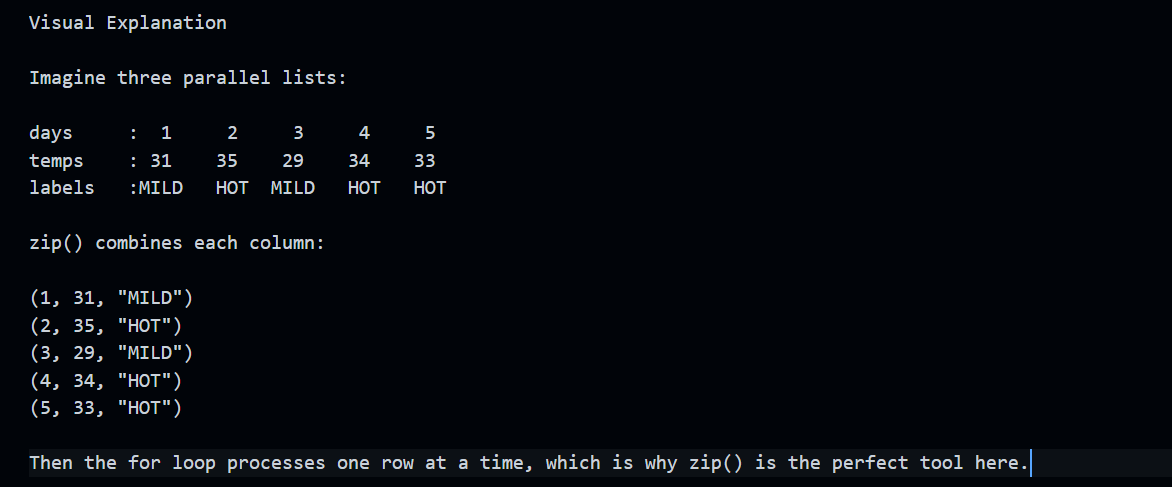

In [12]:
# Label each day HOT / MILD using np.where
labels = np.where(temp >= 33, "HOT", "MILD")
for d, t, lab in zip(data['day'].astype(int), temp, labels):
    print(f"Day {d:2d}: {t:.0f}°C -> {lab}")

Day  1: 31°C -> MILD
Day  2: 34°C -> HOT
Day  3: 29°C -> MILD
Day  4: 27°C -> MILD
Day  5: 33°C -> HOT
Day  6: 36°C -> HOT
Day  7: 30°C -> MILD
Day  8: 28°C -> MILD
Day  9: 35°C -> HOT
Day 10: 32°C -> MILD
Day 11: 26°C -> MILD
Day 12: 37°C -> HOT
Day 13: 33°C -> HOT
Day 14: 30°C -> MILD


## 5. README + push to GitHub (60–70 min)

Create a `README.md` in your repo. A good README answers three things:
**Problem → Approach → Result.**

Example structure:
```
# Weather Data Analyzer (Week 4 Project)

## Problem
Analyze a week of weather data to find patterns in temperature and rainfall.

## Approach
Loaded the CSV with NumPy and computed summary statistics
(mean, min, max, std) and used boolean masks to answer questions.

## Results
- Average temperature: 31.5°C
- Hottest day: Day 12 (37°C)
- Rainy days: 7 out of 14
- Total rainfall: 52 mm
```

**Push steps (from your project folder):**
```
git add .
git commit -m "Week 4: Numeric Data Analyzer with NumPy"
git push
```
Then post the repo link in the WhatsApp group. ✅

## 6. Demos (70–75 min)

Share your screen and show:
1. Your loaded dataset
2. One interesting statistic
3. One question your analysis answered

### Recap
Today you built a real, portfolio-worthy project:
- Loaded a **real CSV** with `np.genfromtxt`
- Computed **summary statistics** on real columns
- Used **masks** and **`np.where`** to answer real questions
- Shipped it to **GitHub** with a clear README

Next week (Week 5): **Pandas** — the tool that makes all of this even easier. 🚀

| Feature            | Description                                                                                                                                                                         | Data Type    | Example       |
| ------------------ | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------ | ------------- |
| **match**          | The match/game number. It uniquely identifies each game.                                                                                                                            | Integer (ID) | `1`, `2`, `3` |
| **points_scored**  | Total points scored by the team in that match. Higher values generally indicate better offensive performance.                                                                       | Integer      | `98`, `120`   |
| **points_allowed** | Total points scored by the opponent against the team. Lower values indicate better defense.                                                                                         | Integer      | `92`, `110`   |
| **rebounds**       | Number of rebounds collected by the team. A rebound occurs when a player gains possession after a missed shot. More rebounds usually mean better control of the game.               | Integer      | `45`, `55`    |
| **assists**        | Number of assists made by the team. An assist is credited when a player's pass directly leads to a teammate scoring. More assists often indicate better teamwork and ball movement. | Integer      | `22`, `33`    |
